### Regression Model Analysis

This notebook builds and evaluates multiple regression models (Linear Regression, Random Forest, and Gradient Boosting) on the ENB2012 dataset to predict heating load (`Y1`) from building features.

#### Visualizations and Interpretation

- **Feature Correlation Matrix**: Shows how each feature is correlated with every other feature and the target.
- **Surface Area vs Heating Load**: Demonstrates the relationship between surface area and heating load, with a fitted regression line.
- **Actual vs Predicted**: Compares predicted values to actual values to show model accuracy.
- **Residual Plot**: Helps identify whether prediction errors are randomly distributed.
- **Error Distribution**: Shows how prediction errors are distributed and whether they are centered around zero.
- **Feature Importance**: Ranks features by how much they contribute to the Random Forest model's predictions.

#### Model Performance Overview

- **R² Score**: Proportion of variance explained by the model.
- **MAE (Mean Absolute Error)**: Average absolute difference between actual and predicted values.
- **RMSE (Root Mean Squared Error)**: Similar to MAE but penalizes larger errors more heavily.

The notebook uses these visualizations and metrics to identify the best model and evaluate prediction quality.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [5]:
df = pd.read_excel("ENB2012_data.xlsx")

df.columns = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area",
    "Glazing Area Distribution", "Y1", "Y2"
]

print(df.head())

   Relative Compactness  Surface Area  Wall Area  Roof Area  Overall Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing Area  Glazing Area Distribution     Y1     Y2  
0            2           0.0                          0  15.55  21.33  
1            3           0.0                          0  15.55  21.33  
2            4           0.0                          0  15.55  21.33  
3            5           0.0                          0  15.55  21.33  
4            2           0.0                          0  20.84  28.28  


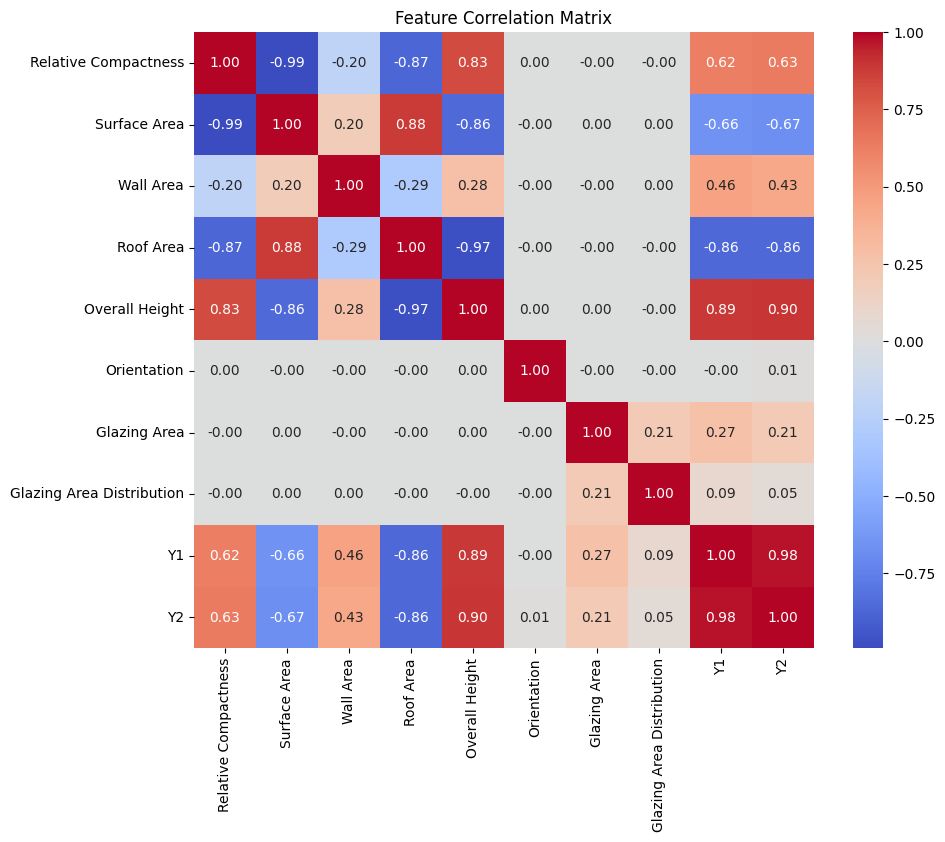

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

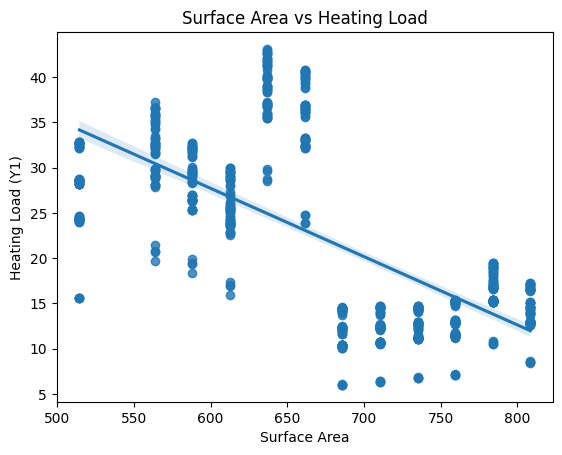

In [ ]:
sns.regplot(x=df['Surface Area'], y=df['Y1'])
plt.xlabel("Surface Area")
plt.ylabel("Heating Load (Y1)")
plt.title("Surface Area vs Heating Load")
plt.show()

In [10]:
X = df.drop(['Y1', 'Y2'], axis=1)
y = df['Y1']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    
    return y_pred

In [16]:
y_pred_lr = evaluate(lr, "Linear Regression")
y_pred_rf = evaluate(rf, "Random Forest")
y_pred_gb = evaluate(gb, "Gradient Boosting")


Linear Regression
R2: 0.9121846294352438
MAE: 2.1820729961539005
RMSE: 3.0254268535103734

Random Forest
R2: 0.9976242618619537
MAE: 0.35731331168831126
RMSE: 0.4976232610633259

Gradient Boosting
R2: 0.9974690322904023
MAE: 0.3853051222597707
RMSE: 0.513623268734873


In [17]:
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("CV R2 (Random Forest):", scores.mean())

CV R2 (Random Forest): 0.9973303697668561


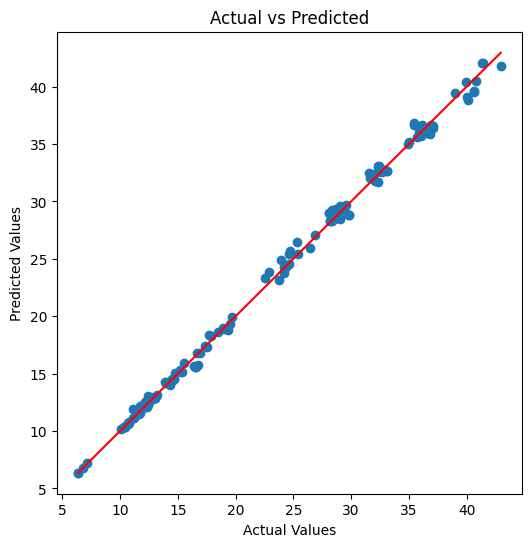

In [ ]:
y_pred = y_pred_rf  # choose best model

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

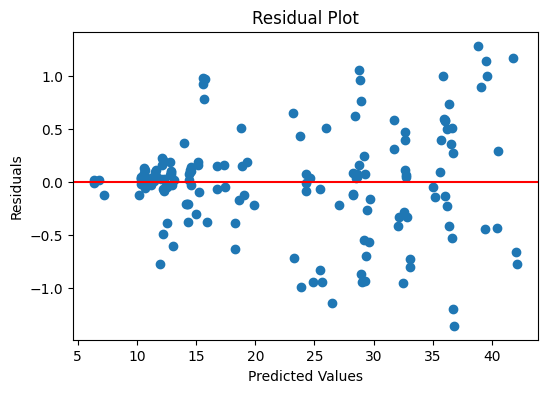

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

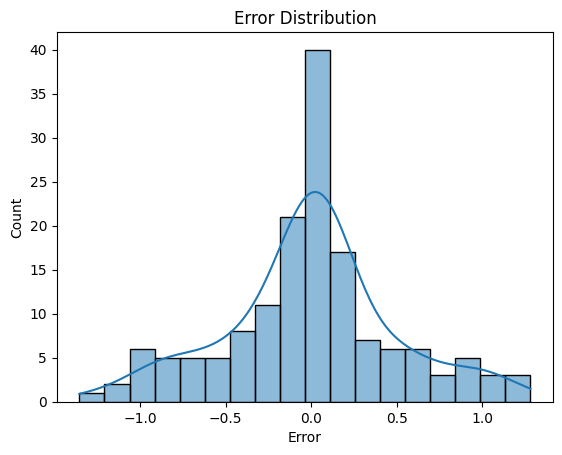

In [ ]:
sns.histplot(residuals, kde=True)

plt.xlabel("Error")
plt.title("Error Distribution")
plt.show()

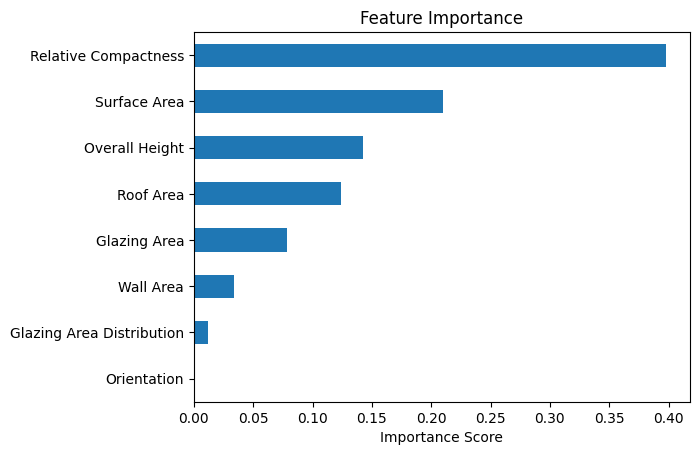

In [ ]:
importance = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values()

feat_imp.plot(kind='barh')
plt.xlabel("Importance Score")
plt.title("Feature Importance")
plt.show()